In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('aslak')
#import pandas as pd
#import xarray as xr

In [3]:
R=8.314

q=np.linspace(40e3,300e3,3)
ts = np.exp(np.linspace(-1,3.5,100))
tm = np.linspace(240,273,110)
Ts,Tm,Q = np.meshgrid(ts,tm,q)
Tm.shape

(110, 100, 3)

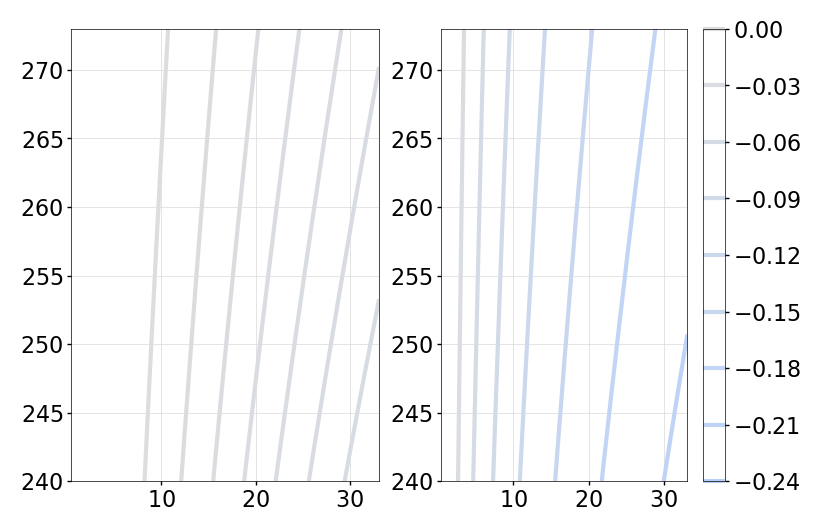

In [ ]:

Afun = lambda Q,T: np.exp(-Q/(R*T))

def A(T):
    A1 = 3.985e-13 * np.exp(-60e3 / (R * T))
    A2 = 1.916e3 * np.exp(-139e3 / (R * T))
    return np.maximum(A1, A2)


def do_it(Q,Tm,Ts,N=1000):
    T = np.cos(np.linspace(0,np.pi,N))*Ts + Tm
    return np.mean(Afun(Q,T))
Abar = np.vectorize(do_it)

logAtrue = np.log(Abar(Q,Tm,Ts))
m=0.85
logAsimple = np.log(Abar(Q,Tm,Ts,N=16))


plt.subplot(1,2,1)
ix=0
plt.contour(Ts[:,:,ix],Tm[:,:,ix],logAtrue[:,:,ix]-logAsimple[:,:,ix],vmin=-1,vmax=1,cmap='coolwarm')
plt.subplot(1,2,2)
ix=2
plt.contour(Ts[:,:,ix],Tm[:,:,ix],logAtrue[:,:,ix]-logAsimple[:,:,ix],vmin=-1,vmax=1,cmap='coolwarm')
plt.colorbar()


In [ ]:

#model = lambda m: np.log((Afun(Q,Tm-Ts*m)+Afun(Q,Tm+Ts*m))/2)
model = lambda m: np.log(Afun(Q,Tm+Ts**2*m/(Tm)))


from scipy.optimize import leastsq
mbest,qqq = leastsq(lambda m:logAtrue-model(m),1)
plt.scatter(Ts, logAtrue - model(mbest),c=Q)
#Q,np.exp(logAtrue- np.log((Afun(Q,Tm-Ts**2/Tm)+Afun(Q,Tm+Ts**2/Tm))/2))


In [ ]:
T = np.sin(np.linspace(0,2*np.pi,10))*Ts[0] + Tm[0]
np.mean(np.exp(-200e3/(R*T)+))

5.809491570473172e-44

In [85]:
-Q/(R*260)

array([[[ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        ...,
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622]],

       [[ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        ...,
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622]],

       [[ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        ...,
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883,  -78.64399252, -138.78351622],
        [ -18.50446883